### Uses R v4.3.3.

# Differential expression analysis of RNA-seq Data using edgeR: A comparative study of Ryan datasets reflecting healthy versus recovered patients with LC symptoms classified as mild or moderate.

### Introduction:

This analysis focuses on the DEGs analysis of three phenotypic attributes from one dataset (Ryan Et al) was reprocessed along with the other datasets in the compendium using the Bwb software.  The edgeR package that analyzed the output of Bwb data was set to FDR < 0.05 and a log2foldchange = 1.25. The DEGs comparison is illustrated in the figure below as pathway (ii) with the overall aim being to identify key genes that reflect significant expression differences between the two groups of participants (Healthy versus those healed from active COVID-19 and reporting Long-Covid (LC) signs and symptoms that were classified as mild or moderate).  Group C was dropped during analsyis in order to allow a 'cleaner' way of balancing the datasets.  A had 14 samples representing the healthy group while C + D had 98 + 11 total sample which leads to an imbalance in category sample sizes with A : C + D = 14 : 109.  By dropping C from analysis, we now have A + D which has a ratio of 14 : 11 while maintaining the meaning of our analysis as healthy versus any LC that is not classifed higher than moderate.

The clincal scores were based on the signs and symptoms as detailed in "NIH. Clinical Spectrum of SARS-CoV-2 Infection 2021" where 5 = "asymptomatic", 4 = "mild", 3 = "moderate", 2 = "severe", and 1 = "critical".

### Specific Objectives

1. **Data Processing** - Importing and cleaning the metadata
2. **Filtering out Low Expression Genes** - Dropping genes with low expression to improve statistical power
3. **Normalization** - Using Trimmed Mean of M-values to adjust for differences in sequencing depth
4. **Differential expression analysis** - Using a negative binomial exact test (see here for the packge documentation)
5. **Extract and interpret top DEGs** - to highlight their biological relevance
6. **Set-up for downstream GSEA** - use the outputs to create rank lists for GSEA (different notebook)



![Study design](./images/Study_design.png)

### Uncomment to install BiocManager and DESeq2.  Comment back out after running once.  It's not necessary to reinstall every time the notebook is ran.

In [1]:
# if (!require("BiocManager", quietly = TRUE))
#     install.packages("BiocManager")
# BiocManager::install(version = "3.18")
# BiocManager::install(c("edgeR"))

### Uncomment out each package individually and run the cell to install each package.  Do this one at a time and watch the terminal output to see if any additional dependencies need to be installed on your system.  This is espeically true on Linux where you need to install other packages from the package manager.

In [2]:
# install.packages('readr', version='2.1.5')
# install.packages('dplyr', version='1.1.4')
# install.packages('plotly', version='4.10.4')

In [3]:
library(readr)
library(dplyr)

library(edgeR)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: limma



### Data Processing - Importing and cleaning the metadata

In this section, we import the normalized counts matrix from Bwb's uniform processing as our input for the Ryan Et al part of the dataset.  We will later filter it to keep only the relevant samples using our sample sheet created using a different notebook.

The input file is cleaned by removing suffixes from the column headers to keep the same convention with all other notebooks in this analsyis.  We will sort the columns for consistency and then perform a sanity check by display the head to show only a few rows of the output.

## Change the Ryan Gene Counts location by updating the read.csv() value.

In [4]:
# Read Ryan counts
ryan.counts <- as.matrix(read.csv("./data/Ryan/genesCounts.csv", sep="\t",row.names="Name"))

# Edit sample names in dataframe
colnames(ryan.counts) <- sapply(strsplit(colnames(ryan.counts), "_"), `[`, 1)

# Order the dataframe by column name
ryan.counts <- ryan.counts[, sort(colnames(ryan.counts))]

head(ryan.counts)

,SRR14076246,SRR14076247,SRR14076248,SRR14076249,SRR14076250,SRR14076251,SRR14076252,SRR14076253,SRR14076254,SRR14076255,⋯,SRR15510595,SRR15510596,SRR15510597,SRR15510598,SRR15510599,SRR15510600,SRR15510601,SRR15510602,SRR15510603,SRR15510604
ENSG00000268674,0,0,0,0,0,0,1,0,2,1,⋯,2,0,5,0,0,0,0,1,1,0
ENSG00000271254,72,50,203,199,96,130,75,76,228,181,⋯,215,318,169,146,269,241,257,154,279,94
ENSG00000275063,2,5,0,0,0,0,5,8,1,0,⋯,9,0,1,4,5,0,0,0,2,0
ENSG00000277856,0,1,0,0,0,0,2,1,0,0,⋯,0,1,0,1,1,0,0,0,0,0
ENSG00000276345,0,0,6,0,0,8,111,72,151,113,⋯,0,0,0,0,5,2,8,432,5,0
ENSG00000278633,4,0,7,7,2,0,10,0,12,2,⋯,9,8,22,1,11,16,19,2,7,0


Although this comparative analysis inputs sample sheet data from one dataset (Ryan Et al), we will perform a sanity check to make certain that the output dataframe has the expected dimensions of 38,592 genes in the rows and 152 total samples in the columns.

In [5]:
# Sanity check
dim(ryan.counts)

[1] 38592   152

### Loading the metadata

Now that we have the normalized data with a counts matrix, we need the metadata which will guide us in 
subsetting our data with respect to clinical attributes like presence or absence of LC, LC severity classification etc. We include the sample sheets for our desired comparisons which are those that were healthy and that have healed from acute COVID-19 and have LC signs and symptoms classified as mild or moderate.

We also prepare the metadata dataset by removing the extra index column, combining all relevant sample sheets for inclusion, then sorting by sample name "Run".

## Change the Compendium metadata locations by updating the read_tsv() values.

In [6]:
# Read Andrew's Compendium data: Group A - Ryan
sample.sheet.healthy.af = read_tsv("./Andrews_Compendium/output/sample_sheet_healthy_af.csv")
sample.sheet.healthy.am = read_tsv("./Andrews_Compendium/output/sample_sheet_healthy_am.csv")

# Remove first column from dataframes
sample.sheet.healthy.af <- sample.sheet.healthy.af[c(2:length(colnames(sample.sheet.healthy.af)))]
sample.sheet.healthy.am <- sample.sheet.healthy.am[c(2:length(colnames(sample.sheet.healthy.am)))]

# Concatenate dataframes
ryan.sample.sheet.healthy <- rbind(sample.sheet.healthy.af, sample.sheet.healthy.am)

# Sort dataframe by Run (Sample) column
ryan.sample.sheet.healthy <- arrange(ryan.sample.sheet.healthy, Run)

ryan.sample.sheet.healthy

New names:
• `` -> `...1`
Rows: 7 Columns: 35
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (26): Run, Assay Type, BioProject, BioSample, Center Name, Consent, DAT...
dbl   (7): ...1, Age, AvgSpotLen, Bases, Bytes, version, RIN
dttm  (2): ReleaseDate, create_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 7 Columns: 35
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (26): Run, Assay Type, BioProject, BioSample, Center Name, Consent, DAT...
dbl   (7): ...1, Age, AvgSpotLen, Bases, Bytes, version, RIN
dttm  (2): ReleaseDate, create_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Run,Age,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,Center Name,Consent,⋯,version,Sample Name,sex,source_name,SRA Study,subject_id,Timepoint,tissue,RIN,Sample_Number
<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
SRR14076274,65,RNA-Seq,300,17132068500,PRJNA717662,SAMN18499988,5577168394,GEO,public,⋯,1,GSM5212344,female,Peripheral blood,SRP312283,HC1,Control,Peripheral blood,8.5,Sample-37
SRR14076275,55,RNA-Seq,300,18290564100,PRJNA717662,SAMN18499987,5941597180,GEO,public,⋯,1,GSM5212345,male,Peripheral blood,SRP312283,HC6,Control,Peripheral blood,8.8,Sample-45
SRR14076280,34,RNA-Seq,300,15407664600,PRJNA717662,SAMN18499982,5011739338,GEO,public,⋯,1,GSM5212350,male,Peripheral blood,SRP312283,HC2,Control,Peripheral blood,8.0,Sample-38
SRR14076281,48,RNA-Seq,300,15462196200,PRJNA717662,SAMN18499981,5036146643,GEO,public,⋯,1,GSM5212351,male,Peripheral blood,SRP312283,HC7,Control,Peripheral blood,8.5,Sample-46
SRR14076285,63,RNA-Seq,300,17168881500,PRJNA717662,SAMN18499909,5593291175,GEO,public,⋯,1,GSM5212355,female,Peripheral blood,SRP312283,HC4,Control,Peripheral blood,8.4,Sample-39
SRR14076286,27,RNA-Seq,300,18766087200,PRJNA717662,SAMN18499946,6099144065,GEO,public,⋯,1,GSM5212356,male,Peripheral blood,SRP312283,HC8,Control,Peripheral blood,8.6,Sample-47
SRR14076291,52,RNA-Seq,300,15353712600,PRJNA717662,SAMN18499941,4995757233,GEO,public,⋯,1,GSM5212361,female,Peripheral blood,SRP312283,HC5,Control,Peripheral blood,7.8,Sample-40
SRR14076292,54,RNA-Seq,300,17904928800,PRJNA717662,SAMN18499940,5852173368,GEO,public,⋯,1,GSM5212362,male,Peripheral blood,SRP312283,HC9,Control,Peripheral blood,8.5,Sample-48
SRR14076319,70,RNA-Seq,300,15545828400,PRJNA717662,SAMN18499928,5062379739,GEO,public,⋯,1,GSM5212389,male,Peripheral blood,SRP312283,HC3,Control,Peripheral blood,8.5,Sample-85


In [7]:
# Reduce and convert ryan_sample_sheet_healthy into sheet that can be concatenated
ryan.sample.sheet.healthy.reduced = ryan.sample.sheet.healthy[c("Run", "disease_severity")]
                                            
ryan.sample.sheet.healthy.reduced                         

Run,disease_severity
<chr>,<chr>
SRR14076274,Healthy
SRR14076275,Healthy
SRR14076280,Healthy
SRR14076281,Healthy
SRR14076285,Healthy
SRR14076286,Healthy
SRR14076291,Healthy
SRR14076292,Healthy
SRR14076319,Healthy


Next, we build a dataframe comprising of all the sample sheets with mild or moderate cases of LC

## Change the Compendium metadata locations by updating the read_tsv() values.

In [8]:
# Read Andrew's Compendium data: Group C - Ryan
sample.sheet.mild.c12f = read_tsv("./Andrews_Compendium/output/sample_sheet_mild_c12f.csv")
sample.sheet.mild.c12m = read_tsv("./Andrews_Compendium/output/sample_sheet_mild_c12m.csv")
sample.sheet.mild.c16f = read_tsv("./Andrews_Compendium/output/sample_sheet_mild_c16f.csv")
sample.sheet.mild.c16m = read_tsv("./Andrews_Compendium/output/sample_sheet_mild_c16m.csv")
sample.sheet.mild.c24f = read_tsv("./Andrews_Compendium/output/sample_sheet_mild_c24f.csv")
sample.sheet.mild.c24m = read_tsv("./Andrews_Compendium/output/sample_sheet_mild_c24m.csv")

# Remove first column from dataframes
sample.sheet.mild.c12f <- sample.sheet.mild.c12f[c(2:length(colnames(sample.sheet.mild.c12f)))]
sample.sheet.mild.c12m <- sample.sheet.mild.c12m[c(2:length(colnames(sample.sheet.mild.c12m)))]
sample.sheet.mild.c16f <- sample.sheet.mild.c16f[c(2:length(colnames(sample.sheet.mild.c16f)))]
sample.sheet.mild.c16m <- sample.sheet.mild.c16m[c(2:length(colnames(sample.sheet.mild.c16m)))]
sample.sheet.mild.c24f <- sample.sheet.mild.c24f[c(2:length(colnames(sample.sheet.mild.c24f)))]
sample.sheet.mild.c24m <- sample.sheet.mild.c24m[c(2:length(colnames(sample.sheet.mild.c24m)))]

# Concatenate dataframes
sample.sheet.mild.c12 <- rbind(sample.sheet.mild.c12f, sample.sheet.mild.c12m)
sample.sheet.mild.c16 <- rbind(sample.sheet.mild.c16f, sample.sheet.mild.c16m)
sample.sheet.mild.c24 <- rbind(sample.sheet.mild.c24f, sample.sheet.mild.c24m)

ryan.sample.sheet.mild <- do.call("rbind", list(sample.sheet.mild.c12, sample.sheet.mild.c16, sample.sheet.mild.c24))

# Sort dataframe by Run (Sample) column
ryan.sample.sheet.mild <- arrange(ryan.sample.sheet.mild, Run)

ryan.sample.sheet.mild

New names:
• `` -> `...1`
Rows: 9 Columns: 35
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (25): Run, Assay Type, BioProject, BioSample, Center Name, Consent, DAT...
dbl   (7): ...1, Age, AvgSpotLen, Bases, Bytes, version, RIN
lgl   (1): Sample_Number
dttm  (2): ReleaseDate, create_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 7 Columns: 35
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (25): Run, Assay Type, BioProject, BioSample, Center Name, Consent, DAT...
dbl   (7): ...1, Age, AvgSpotLen, Bases, Bytes, version, RIN
lgl   (1): Sample_Number
dttm  (2): ReleaseDate, create_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Run,Age,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,Center Name,Consent,⋯,version,Sample Name,sex,source_name,SRA Study,subject_id,Timepoint,tissue,RIN,Sample_Number
<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
SRR14076246,29.8,RNA-Seq,300,19026171000,PRJNA717662,SAMN18500009,6213883977,GEO,public,⋯,1,GSM5212316,male,Peripheral blood,SRP312283,15-063,16wpi,Peripheral blood,8.6,Sample-1
SRR14076247,29.8,RNA-Seq,300,16951261500,PRJNA717662,SAMN18500008,5523576479,GEO,public,⋯,1,GSM5212317,male,Peripheral blood,SRP312283,15-063,24wpi,Peripheral blood,8.7,Sample-9
SRR14076252,76.1,RNA-Seq,300,16698577500,PRJNA717662,SAMN18500003,5450288161,GEO,public,⋯,1,GSM5212322,male,Peripheral blood,SRP312283,15-050,16wpi,Peripheral blood,8.1,Sample-2
SRR14076253,76.1,RNA-Seq,300,18717522600,PRJNA717662,SAMN18500002,6058806086,GEO,public,⋯,1,GSM5212323,male,Peripheral blood,SRP312283,15-050,24wpi,Peripheral blood,7.3,Sample-10
SRR14076256,69.5,RNA-Seq,300,21218648700,PRJNA717662,SAMN18499999,6906334751,GEO,public,⋯,1,GSM5212326,female,Peripheral blood,SRP312283,15-015,16wpi,Peripheral blood,9.1,Sample-34
SRR14076257,69.5,RNA-Seq,300,20664495600,PRJNA717662,SAMN18500028,6689387906,GEO,public,⋯,1,GSM5212327,female,Peripheral blood,SRP312283,15-015,24wpi,Peripheral blood,8.2,Sample-42
SRR14076258,67.2,RNA-Seq,300,16489622400,PRJNA717662,SAMN18500027,5377492241,GEO,public,⋯,1,GSM5212328,male,Peripheral blood,SRP312283,15-008,16wpi,Peripheral blood,9.0,Sample-3
SRR14076259,67.2,RNA-Seq,300,15629641200,PRJNA717662,SAMN18500026,5060926011,GEO,public,⋯,1,GSM5212329,male,Peripheral blood,SRP312283,15-008,24wpi,Peripheral blood,7.1,Sample-11
SRR14076260,73.5,RNA-Seq,300,19477144200,PRJNA717662,SAMN18500025,6376736797,GEO,public,⋯,1,GSM5212330,male,Peripheral blood,SRP312283,15-026,16wpi,Peripheral blood,9.2,Sample-19


In [9]:
# Reduce and convert ryan_sample_sheet_mild into sheet that can be concatenated
ryan.sample.sheet.mild.reduced = ryan.sample.sheet.mild[c("Run", "disease_severity")]

ryan.sample.sheet.mild.reduced$disease_severity <- rep("Mild/Moderate", length(ryan.sample.sheet.mild.reduced$disease_severity))
                                            
ryan.sample.sheet.mild.reduced             

Run,disease_severity
<chr>,<chr>
SRR14076246,Mild/Moderate
SRR14076247,Mild/Moderate
SRR14076252,Mild/Moderate
SRR14076253,Mild/Moderate
SRR14076256,Mild/Moderate
SRR14076257,Mild/Moderate
SRR14076258,Mild/Moderate
SRR14076259,Mild/Moderate
SRR14076260,Mild/Moderate


## Change the Compendium metadata locations by updating the read_tsv() values.

In [10]:
# Read Andrew's Compendium data: Group D - Ryan
sample.sheet.moderate.d12f = read_tsv("./Andrews_Compendium/output/sample_sheet_moderate_d12f.csv")
sample.sheet.moderate.d12m = read_tsv("./Andrews_Compendium/output/sample_sheet_moderate_d12m.csv")
sample.sheet.moderate.d16f = read_tsv("./Andrews_Compendium/output/sample_sheet_moderate_d16f.csv")
sample.sheet.moderate.d16m = read_tsv("./Andrews_Compendium/output/sample_sheet_moderate_d16m.csv")
sample.sheet.moderate.d24f = read_tsv("./Andrews_Compendium/output/sample_sheet_moderate_d24f.csv")
sample.sheet.moderate.d24m = read_tsv("./Andrews_Compendium/output/sample_sheet_moderate_d24m.csv")

# Remove first column from dataframes
sample.sheet.moderate.d12f <- sample.sheet.moderate.d12f[c(2:length(colnames(sample.sheet.moderate.d12f)))]
sample.sheet.moderate.d12m <- sample.sheet.moderate.d12m[c(2:length(colnames(sample.sheet.moderate.d12m)))]
sample.sheet.moderate.d16f <- sample.sheet.moderate.d16f[c(2:length(colnames(sample.sheet.moderate.d16f)))]
sample.sheet.moderate.d16m <- sample.sheet.moderate.d16m[c(2:length(colnames(sample.sheet.moderate.d16m)))]
sample.sheet.moderate.d24f <- sample.sheet.moderate.d24f[c(2:length(colnames(sample.sheet.moderate.d24f)))]
sample.sheet.moderate.d24m <- sample.sheet.moderate.d24m[c(2:length(colnames(sample.sheet.moderate.d24m)))]

# Concatenate dataframes
sample.sheet.moderate.d12 <- rbind(sample.sheet.moderate.d12f, sample.sheet.moderate.d12m)
sample.sheet.moderate.d16 <- rbind(sample.sheet.moderate.d16f, sample.sheet.moderate.d16m)
sample.sheet.moderate.d24 <- rbind(sample.sheet.moderate.d24f, sample.sheet.moderate.d24m)

ryan.sample.sheet.moderate <- do.call("rbind", list(sample.sheet.moderate.d12, sample.sheet.moderate.d16, sample.sheet.moderate.d24))

# Sort dataframe by Run (Sample) column
ryan.sample.sheet.moderate <- arrange(ryan.sample.sheet.moderate, Run)

ryan.sample.sheet.moderate

New names:
• `` -> `...1`
Rows: 1 Columns: 35
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (25): Run, Assay Type, BioProject, BioSample, Center Name, Consent, DAT...
dbl   (7): ...1, Age, AvgSpotLen, Bases, Bytes, version, RIN
lgl   (1): Sample_Number
dttm  (2): ReleaseDate, create_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 0 Columns: 35
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (35): ...1, Run, Age, Assay Type, AvgSpotLen, Bases, BioProject, BioSamp...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 3 Columns: 35
── Column specification ────────────────────────────────────────────────────

Run,Age,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,Center Name,Consent,⋯,version,Sample Name,sex,source_name,SRA Study,subject_id,Timepoint,tissue,RIN,Sample_Number
<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
SRR14076297,51.10000,RNA-Seq,300,15851832300,PRJNA717662,SAMN18499933,5156406801,GEO,public,⋯,1,GSM5212367,female,Peripheral blood,SRP312283,15-037,16wpi,Peripheral blood,9.0,Sample-81
SRR14076298,51.10000,RNA-Seq,300,19533942600,PRJNA717662,SAMN18499932,6312725178,GEO,public,⋯,1,GSM5212368,female,Peripheral blood,SRP312283,15-037,24wpi,Peripheral blood,9.1,Sample-89
SRR14076299,64.90000,RNA-Seq,300,16746889800,PRJNA717662,SAMN18499931,5473582100,GEO,public,⋯,1,GSM5212369,female,Peripheral blood,SRP312283,15-040,16wpi,Peripheral blood,8.9,Sample-66
SRR14076300,64.90000,RNA-Seq,300,19757987400,PRJNA717662,SAMN18499938,6410793359,GEO,public,⋯,1,GSM5212370,female,Peripheral blood,SRP312283,15-040,24wpi,Peripheral blood,8.4,Sample-74
SRR14076303,52.90000,RNA-Seq,300,18222311100,PRJNA717662,SAMN18499929,5932113919,GEO,public,⋯,1,GSM5212373,male,Peripheral blood,SRP312283,15-061,16wpi,Peripheral blood,8.5,Sample-51
SRR14076304,52.90000,RNA-Seq,300,19742743500,PRJNA717662,SAMN18499964,6428464748,GEO,public,⋯,1,GSM5212374,male,Peripheral blood,SRP312283,15-061,24wpi,Peripheral blood,9.1,Sample-59
SRR14076333,57.80000,RNA-Seq,300,17820821700,PRJNA717662,SAMN18499914,5816481557,GEO,public,⋯,1,GSM5212403,female,Peripheral blood,SRP312283,15-023,16wpi,Peripheral blood,9.1,Sample-72
SRR14076334,57.80000,RNA-Seq,300,20503934400,PRJNA717662,SAMN18499913,6663696110,GEO,public,⋯,1,GSM5212404,female,Peripheral blood,SRP312283,15-023,24wpi,Peripheral blood,9.0,Sample-80
SRR15510566,57.84110,RNA-Seq,289,26287632800,PRJNA717662,SAMN20848666,8439841963,GEO,public,⋯,1,GSM5527522,female,Peripheral blood,SRP312283,15-023,12wpi,Peripheral blood,9.0,NA


In [11]:
# Reduce and convert ryan_sample_sheet_moderate into sheet that can be concatenated
ryan.sample.sheet.moderate.reduced = ryan.sample.sheet.moderate[c("Run", "disease_severity")]

ryan.sample.sheet.moderate.reduced$disease_severity <- rep("Mild/Moderate", length(ryan.sample.sheet.moderate.reduced$disease_severity))
                                            
ryan.sample.sheet.moderate.reduced

Run,disease_severity
<chr>,<chr>
SRR14076297,Mild/Moderate
SRR14076298,Mild/Moderate
SRR14076299,Mild/Moderate
SRR14076300,Mild/Moderate
SRR14076303,Mild/Moderate
SRR14076304,Mild/Moderate
SRR14076333,Mild/Moderate
SRR14076334,Mild/Moderate
SRR15510566,Mild/Moderate


In [12]:
# Create dataframe from Gene Counts that only contains samples from compendium
ryan.group.a.counts.of.interest <- ryan.counts[, ryan.sample.sheet.healthy$Run]

head(ryan.group.a.counts.of.interest)

,SRR14076274,SRR14076275,SRR14076280,SRR14076281,SRR14076285,SRR14076286,SRR14076291,SRR14076292,SRR14076319,SRR14076320,SRR14076325,SRR14076326,SRR14076331,SRR14076332
ENSG00000268674,0,0,0,2,0,0,0,0,1,0,0,0,0,1
ENSG00000271254,153,68,59,141,87,127,97,161,129,149,71,271,138,178
ENSG00000275063,0,0,0,0,0,2,5,10,14,1,8,2,8,0
ENSG00000277856,0,0,0,0,0,4,0,0,1,1,1,1,1,0
ENSG00000276345,0,110,80,0,2,2,0,239,0,2,7,0,140,149
ENSG00000278633,0,14,2,6,2,0,0,0,6,0,1,12,0,0


In [13]:
# Create dataframe from Gene Counts that only contains samples from compendium
ryan.group.c.counts.of.interest <- ryan.counts[, ryan.sample.sheet.mild$Run]

head(ryan.group.c.counts.of.interest)

,SRR14076246,SRR14076247,SRR14076252,SRR14076253,SRR14076256,SRR14076257,SRR14076258,SRR14076259,SRR14076260,SRR14076261,⋯,SRR15510594,SRR15510595,SRR15510596,SRR15510597,SRR15510598,SRR15510599,SRR15510600,SRR15510601,SRR15510602,SRR15510604
ENSG00000268674,0,0,1,0,0,0,0,0,0,0,⋯,1,2,0,5,0,0,0,0,1,0
ENSG00000271254,72,50,75,76,147,109,245,158,176,130,⋯,380,215,318,169,146,269,241,257,154,94
ENSG00000275063,2,5,5,8,6,6,0,0,7,5,⋯,10,9,0,1,4,5,0,0,0,0
ENSG00000277856,0,1,2,1,1,0,0,0,0,0,⋯,0,0,1,0,1,1,0,0,0,0
ENSG00000276345,0,0,111,72,107,59,5,0,230,123,⋯,0,0,0,0,0,5,2,8,432,0
ENSG00000278633,4,0,10,0,10,6,2,0,4,12,⋯,3,9,8,22,1,11,16,19,2,0


In [14]:
# Create dataframe from Gene Counts that only contains samples from compendium
ryan.group.d.counts.of.interest <- ryan.counts[, ryan.sample.sheet.moderate$Run]

head(ryan.group.d.counts.of.interest)

,SRR14076297,SRR14076298,SRR14076299,SRR14076300,SRR14076303,SRR14076304,SRR14076333,SRR14076334,SRR15510566,SRR15510588,SRR15510603
ENSG00000268674,0,1,2,0,0,1,0,0,2,0,1
ENSG00000271254,161,163,194,330,231,376,426,585,722,182,279
ENSG00000275063,11,10,6,0,2,1,2,7,5,4,2
ENSG00000277856,1,2,1,1,0,0,0,1,0,3,0
ENSG00000276345,2,0,0,0,239,241,2,0,0,9,5
ENSG00000278633,10,6,32,15,2,5,0,1,5,2,7


Next, we combine the all three phenotypic data (healthy, mild LC, and moderate LC) to have a comprehensive list of these clinical attributes.

In [15]:
# Concatinate Ryan and Yin counts of interest
counts.of.interest <- do.call("cbind", list(ryan.group.a.counts.of.interest, ryan.group.c.counts.of.interest, ryan.group.d.counts.of.interest))

dim(counts.of.interest)

[1] 38592   123

We then perform a filtering step that removes any rows of genes that conatin all zeros in every column. This will not affect analysis negatively and will save on computational resources during iterative analysis. As we can see below. This step reduced the dimensions of the dataframe to 36,040 genes (rows) from 38,592 while keeping the 123 total samples.

In [16]:
# Remove Genes that only contain 0s
counts.of.interest.filtered <- counts.of.interest[apply(counts.of.interest != 0, 1, sum) != 0,]
dim(counts.of.interest.filtered)

[1] 36040   123

In [17]:
# Concatinate Ryan and Yin metadata
metadata <- rbind(ryan.sample.sheet.healthy, ryan.sample.sheet.mild, ryan.sample.sheet.moderate)

metadata$disease_severity <- factor(metadata$disease_severity)

metadata

Run,Age,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,Center Name,Consent,⋯,version,Sample Name,sex,source_name,SRA Study,subject_id,Timepoint,tissue,RIN,Sample_Number
<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
SRR14076274,65.0,RNA-Seq,300,17132068500,PRJNA717662,SAMN18499988,5577168394,GEO,public,⋯,1,GSM5212344,female,Peripheral blood,SRP312283,HC1,Control,Peripheral blood,8.5,Sample-37
SRR14076275,55.0,RNA-Seq,300,18290564100,PRJNA717662,SAMN18499987,5941597180,GEO,public,⋯,1,GSM5212345,male,Peripheral blood,SRP312283,HC6,Control,Peripheral blood,8.8,Sample-45
SRR14076280,34.0,RNA-Seq,300,15407664600,PRJNA717662,SAMN18499982,5011739338,GEO,public,⋯,1,GSM5212350,male,Peripheral blood,SRP312283,HC2,Control,Peripheral blood,8.0,Sample-38
SRR14076281,48.0,RNA-Seq,300,15462196200,PRJNA717662,SAMN18499981,5036146643,GEO,public,⋯,1,GSM5212351,male,Peripheral blood,SRP312283,HC7,Control,Peripheral blood,8.5,Sample-46
SRR14076285,63.0,RNA-Seq,300,17168881500,PRJNA717662,SAMN18499909,5593291175,GEO,public,⋯,1,GSM5212355,female,Peripheral blood,SRP312283,HC4,Control,Peripheral blood,8.4,Sample-39
SRR14076286,27.0,RNA-Seq,300,18766087200,PRJNA717662,SAMN18499946,6099144065,GEO,public,⋯,1,GSM5212356,male,Peripheral blood,SRP312283,HC8,Control,Peripheral blood,8.6,Sample-47
SRR14076291,52.0,RNA-Seq,300,15353712600,PRJNA717662,SAMN18499941,4995757233,GEO,public,⋯,1,GSM5212361,female,Peripheral blood,SRP312283,HC5,Control,Peripheral blood,7.8,Sample-40
SRR14076292,54.0,RNA-Seq,300,17904928800,PRJNA717662,SAMN18499940,5852173368,GEO,public,⋯,1,GSM5212362,male,Peripheral blood,SRP312283,HC9,Control,Peripheral blood,8.5,Sample-48
SRR14076319,70.0,RNA-Seq,300,15545828400,PRJNA717662,SAMN18499928,5062379739,GEO,public,⋯,1,GSM5212389,male,Peripheral blood,SRP312283,HC3,Control,Peripheral blood,8.5,Sample-85


Next, we will create a DGEList object which will be the foundation of our analysis. This method (See help() of 
the package) will help us filter genes based on expression levels, normalize the gene counts, create a design matrix
for comparison, then it will estimate dispersion (which is the variance in gene expression). After this, it will perform statistical testing.


In [18]:
# Defining two groups and assigning to the variable "group"
group <- factor(c(rep(1,14), rep(2, 109)))

In [19]:
# Preparing the data for normalization, filtering, and DEA,  Assigning it to a variable 'y'
y <- DGEList(counts=counts.of.interest.filtered, group=group)

In [20]:
# Filtering out genes to keep only those with more than 3 copies per million in at least 5 samples.
dim(y)
keep <- rowSums(cpm(y)>3) > 5
table(keep)

[1] 36040   123

keep
FALSE  TRUE 
22195 13845 

In [21]:
# Removing those genes that were filter out to only keep the 13,845 genes
y <- y[keep, , keep.lib.sizes=FALSE]
tokeep = rownames(y)
dim(y)

[1] 13845   123

In [22]:
# Normalization with edgeR
y <- calcNormFactors(y)

In [23]:
# Creating the Design matrix
design <- model.matrix(~group)

In [24]:
# Estimating dispersions
y <- estimateDisp(y)

Using classic mode.



In [25]:
# Inferring differential expression
et <- exactTest(y)

In [26]:
# Subsetting top DEGs
top20.genes <- rownames(topTags(et, n=20)$table)
top50.genes <- rownames(topTags(et, n=50)$table)
top100.genes <- rownames(topTags(et, n=100)$table)

In [27]:
# Obtaining expression levels of top 20 genes from counts of interest
raw.cnts.top20 <- counts.of.interest[top20.genes, ]

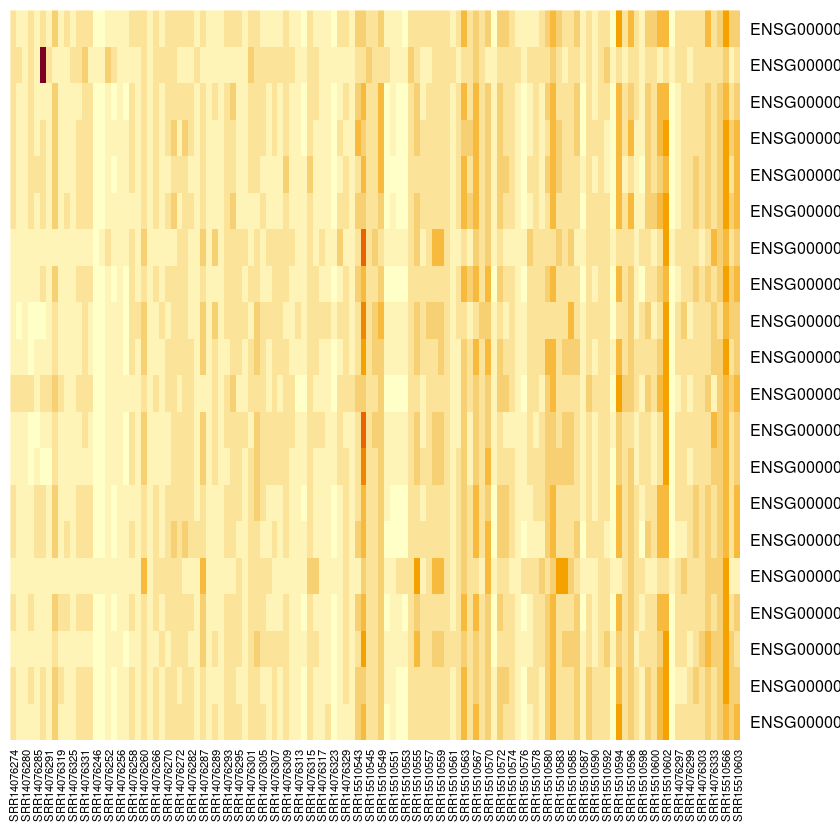

In [28]:
# Heatmap visualization of top 20 genes
heatmap(as.matrix(raw.cnts.top20), Colv=NA, Rowv=NA)

In [29]:
# Obtaining expression levels of top 50 genes from counts of interest
raw.cnts.top50 <- counts.of.interest[top50.genes, ]

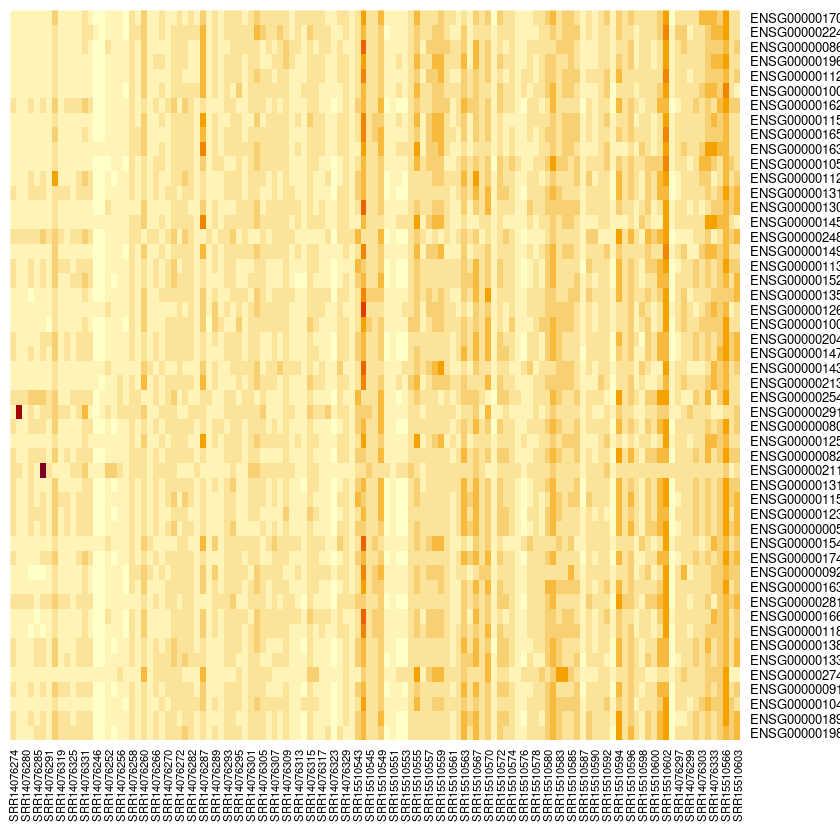

In [30]:
# Heatmap visualization of top 50 genes
heatmap(as.matrix(raw.cnts.top50), Colv=NA, Rowv=NA)

In [31]:
# Obtaining expression levels of top 100 genes from counts of interest
raw.cnts.top100 <- counts.of.interest[top100.genes, ]

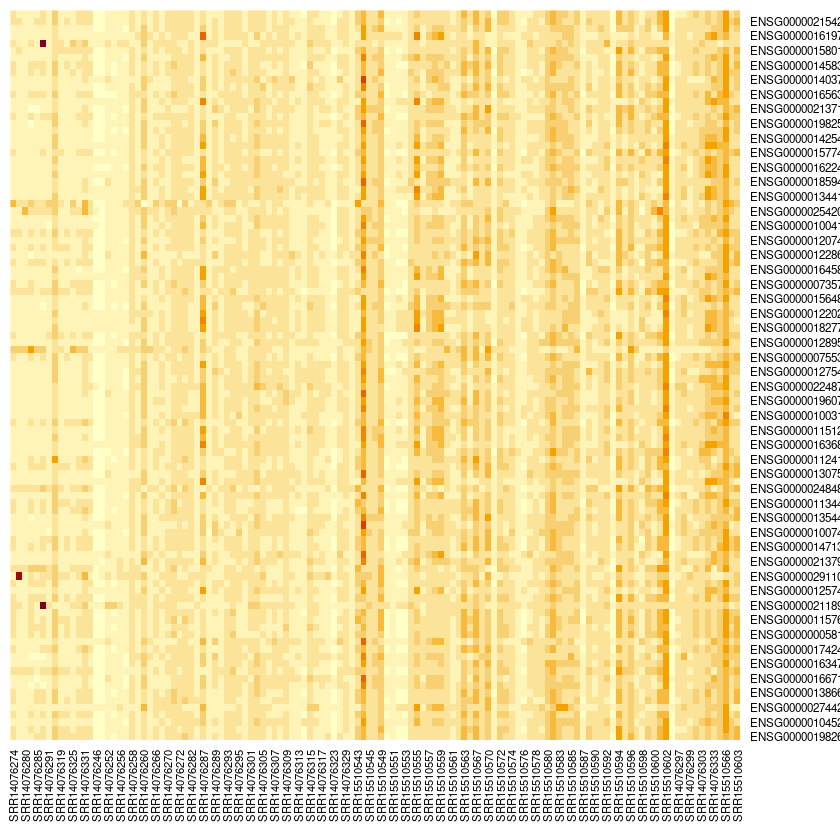

In [32]:
# Heatmap visualization of top 100 genes
heatmap(as.matrix(raw.cnts.top100), Colv=NA, Rowv=NA)

In [33]:
# Extracting the top differentially expressed genes
deg_results_AvsCD <- topTags(et, n = Inf)$table
head(deg_results_AvsCD)

,logFC,logCPM,PValue,FDR
,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000198265,-0.2333798,7.704536,2.085601e-11,2.887515e-07
ENSG00000189079,-0.2374323,6.665686,1.471263e-10,7.334249e-07
ENSG00000104529,0.3847230,8.108644,1.589220e-10,7.334249e-07
ENSG00000091157,-0.2295291,6.173784,3.365260e-10,1.164801e-06
ENSG00000274422,2.0769941,3.212451,4.828419e-10,1.255223e-06
ENSG00000133226,-0.2401804,7.334629,5.439752e-10,1.255223e-06


### Notice

The next slide can be saved as a .csv excel spread sheet by uncommenting the code snippet while leaving the comment with the '#'.

In [34]:
# Ensure row names (gene IDs) are saved as a column
#deg_results_AvsCD$GeneID <- rownames(deg_results_AvsCD)

# Save the file with GeneID included
#write.csv(deg_results_AvsCD, file = file.path(getwd(), "deg_results_AvsCD.csv"), row.names = FALSE)
